Wavelength Re-calibration with LFC
===================================

This tutorial demonstrates how to perform wavelength recalibration using a laser frequency comb (LFC).

The initial wavelength solution, which is roughly determined using ThAr lines, is refined using the LFC. 
The LFC provides a set of lines that are evenly spaced in frequency space, enabling highly precise recalibration.

This methodology was originally developed by T. Hirano (`Hirano et al. 2020 <https://ui.adsabs.harvard.edu/abs/2020PASJ...72...93H/abstract>`_).

- :ref:`step0`
- :ref:`step1`
- :ref:`step2`

.. _step0: 

## Step 0: Preparation

Required data:
1. Target spectra with an initial wavelength solution (created by IRD_stream.py)
2. LFC spectra with wavelength information, generated using the same procedure as the target spectra (as followings)

LFC dataset (comb_data.tar.gz) can be downloaded from the `Zenodo repository <https://doi.org/10.5281/zenodo.14614003>`_

In [ ]:
# Add the following code at the end of IRD_stream.py to generate the LFC spectra:
"""
datadir_comb = basedir/'comb/'
comb_id = [14733, 14832]

comb_master = irdstream.Stream2D("comb_master",
                            datadir_comb,
                            anadir,
                            fitsid=list(range(comb_id[0], comb_id[-1]+1)),
                            rawtag=rawtag,
                            band=band)
comb_master.trace = trace_mmf
comb_master.clean_pattern(trace_mask=trace_mask,
                     extin='', 
                     extout='_cp', 
                     hotpix_mask=hotpix_mask)
comb_master.imcomb = True
comb_master.apext_flatfield(df_flatn, hotpix_mask=hotpix_mask)
comb_master.dispcor(master_path=thar.anadir, blaze=False)
"""

After running the script, confirm that a new file (e.g., `wcomb_master_h_m2.dat') has been created in the specified analysis directory.

In this tutorial, we use data obtained with IRD where LFC light is injected into both fibers.
Alternatively, users may use `COMB_STAR' or `COMB_COMB' data for mmf2 or mmf1 recalibration, respectively (See also the notes in :ref:`terms-calibration`).

.. _step1: 

## Step 1: Settings

Set the data path and analysis parameters, including:
- spectral band (e.g., H band)
- fiber (mmf1 or mmf2)
- prefix of the 1D spectrum files

The following example shows the case of analyzing normalized H-band spectra (nw41511_m2.dat).

In [1]:
from pyird.utils import irdstream
import pathlib

In [2]:
basedir = pathlib.Path('~/pyird/data/20210317/').expanduser()

band = 'h' #'h' or 'y'
mmf = 'mmf2' #'mmf1' (comb fiber) or 'mmf2' (star fiber)

rawdir = basedir/'reduc/'
anadir_1d = basedir/'reduc_1d/'

# last 5 digits of FITS file numbers: [start, end file number]
target_id = [41510, 41511] # target image
target_prefix = "nw" # "nw" or "w"

.. _step2: 

## Step 2: Re-calibration

The data to be analyzed can be specified using the `Stream1D' class:

In [3]:
target_1d = irdstream.Stream1D("target_1d", 
                               rawdir=rawdir, 
                               anadir=anadir_1d, 
                               fitsid=list(range(target_id[0], target_id[-1], 2)),
                               prefix=target_prefix, 
                               extension=f"_m{mmf[-1]}", # fiber
                               inst="IRD",
                               band=band)

fitsid is incremented.
Processing h band
Processing fitsid: [41511]


Next, specify the path to the LFC spectrum.

By applying the `recalibrate_wavelength_with_comb' function, the wavelength solution of the target spectra will be updated using the LFC.

    1. Estimate the theoretical wavelengths of the LFC lines
    2. Fit each comb line with a Gaussian profile to determine the peak pixel positions
    3. Iteratively fit pixel-wavelength relation using an `n_poly'-order polynomial
    4. Allocate the recalibrated wavelengths to the target spectra

The output spectra (**p..._m?.dat** or **nfp..._m?.dat**) will be saved in: `anadir_1d = basedir/'reduc_1d''.

The function returns the recalibrated LFC spectrum (`df_recalib'), which can be used for verification and diagnostics.

In [4]:
comb_master_path = rawdir / f"wcomb_master_{band}_m{mmf[-1]}.dat"
df_recalib = target_1d.recalibrate_wavelength_with_comb(comb_master_path, fiber=mmf, n_poly=6)

[STEP] Recalibrating wavelength with LFC...


  0%|          | 0/21 [00:00<?, ?it/s]/Users/yuikasagi/git/pyird/src/pyird/spec/wavrecal.py:420: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_recalib = pd.concat([df_recalib, df_recalib_ord], ignore_index=True)
/Users/yuikasagi/git/pyird/src/pyird/spec/wavrecal.py:238: RuntimeWarning: divide by zero encountered in matmul
  chisq = np.sum(((y - A @ coeffs) / sig) ** 2)
/Users/yuikasagi/git/pyird/src/pyird/spec/wavrecal.py:238: RuntimeWarning: overflow encountered in matmul
  chisq = np.sum(((y - A @ coeffs) / sig) ** 2)
/Users/yuikasagi/git/pyird/src/pyird/spec/wavrecal.py:238: RuntimeWarning: invalid value encountered in matmul
  chisq = np.sum(((y - A @ coeffs) / sig) ** 2)
/Users/yuikasagi/git/pyird/src/pyird/spec/wavrecal.py:246: Run

recalibrating wavelength with comb: output = pfw41511_m2.dat


Finally, let's check whether the recalibration has been successfully applied:

In [5]:
import pandas as pd

read_args = dict(sep='\s+', header=None, names=["wav", "order", "flux"])
df_calib_thar = pd.read_csv(comb_master_path, **read_args)

orders = df_calib_thar["order"].unique()

<>:3: SyntaxWarning: invalid escape sequence '\s'
<>:3: SyntaxWarning: invalid escape sequence '\s'
/var/folders/sb/rxwbk6kd4gldqpdvzxnhq4xm0000gn/T/ipykernel_52551/2105295559.py:3: SyntaxWarning: invalid escape sequence '\s'
  read_args = dict(sep='\s+', header=None, names=["wav", "order", "flux"])


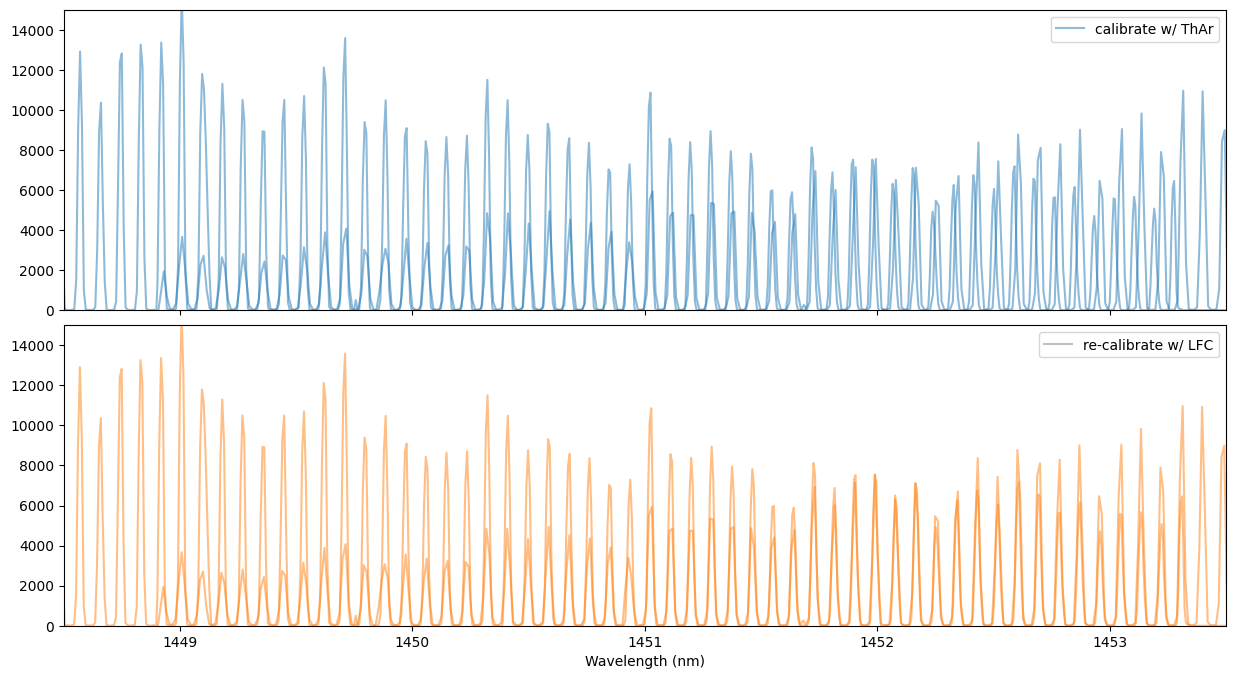

In [21]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(2, 1, figsize=(15,8), sharex=True, sharey=True, gridspec_kw={'hspace': 0.05})

for ord in orders:
    df_calib_ord = df_calib_thar[df_calib_thar['order']==ord]
    df_recalib_ord = df_recalib[df_recalib['order']==ord]
    if target_1d.band == 'h':
        ord += 51
    if (19 <= ord <= 50) or (53 <= ord <= 71):
        color_recalib = 'C1'
    else:
        color_recalib = 'grey'
    axs[0].plot(df_calib_ord['wav'], df_calib_ord['flux'], color='C0', alpha=0.5)
    axs[1].plot(df_recalib_ord['wav'], df_recalib_ord['flux'], color=color_recalib, alpha=0.5)

axs[0].legend(['calibrate w/ ThAr'], loc='upper right')
axs[1].legend(['re-calibrate w/ LFC'], loc='upper right')
axs[0].set(ylim=(0,1.5e4), xlim=(1448.5, 1453.5))
axs[1].set(xlabel='Wavelength (nm)')
plt.show()

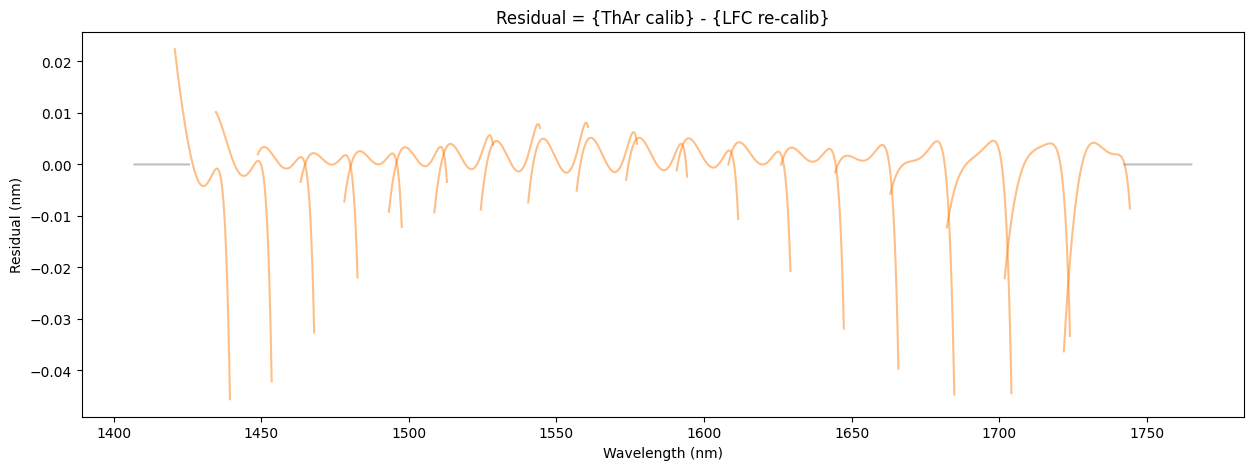

In [10]:
fig, ax = plt.subplots(figsize=(15,5))
for ord in orders:
    df_calib_ord = df_calib_thar[df_calib_thar['order']==ord]
    df_recalib_ord = df_recalib[df_recalib['order']==ord]
    if target_1d.band == 'h':
        ord += 51
    if (19 <= ord <= 50) or (53 <= ord <= 71):
        color = 'C1'
    else:
        color = 'grey'
    ax.plot(df_calib_ord['wav'], df_calib_ord['wav'] - df_recalib_ord['wav'], color=color, alpha=0.5)

ax.set(title='Residual = {ThAr calib} - {LFC re-calib}')
ax.set(xlabel='Wavelength (nm)', ylabel='Residual (nm)')
plt.show()